In [1]:
import paddle
from paddle.io import Dataset
from paddlenlp.data import Vocab

import numpy as np
import string
import random
import matplotlib.pyplot as plt
from functools import partial
from collections import Counter

c:\Users\zetad\anaconda3\envs\es\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\_distutils_hack\__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
c:\Users\zetad\anaconda3\envs\es\lib\site-packages\j

In [2]:
text_file='spa.txt' 

# Define special tags
START_TOKEN = '[start]'
END_TOKEN = '[end]'
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'

In [3]:
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    spa = "[start] " + spa + " [end]"
    text_pairs.append((eng, spa))

In [4]:
# Proper noun detection and marking
# Strategy: Count the word frequency of each word (retaining uppercase and lowercase) in all data
# Capitalize the first letter of the non-sentence position, have low word frequency (<=3), and the exact same word appears in the corresponding translation -> proper noun
# Replace it with <proper> word form, and the translation will be replaced simultaneously

PROPER_FREQ_THRESHOLD = 3  # Word frequency threshold, adjustable

# 1. Count English word frequency (retain uppercase and lowercase, remove punctuation)
strip_chars_proper = string.punctuation + '¿¡'
strip_chars_proper = strip_chars_proper.replace('[', '').replace(']', '')

def tokenize_raw(text):
    out = ''
    for c in text:
        if c not in strip_chars_proper:
            out += c
    return out.split()

eng_word_freq = Counter()
for eng, spa in text_pairs:
    eng_word_freq.update(tokenize_raw(eng))

# 2. Identify proper nouns: Capitalize the first letter of the non-sentence position + low word frequency + exactly the same word appears in the translation
proper_nouns = set()
for eng, spa in text_pairs:
    words = tokenize_raw(eng)
    spa_words = set(tokenize_raw(spa))
    for i, w in enumerate(words):
        if i == 0:
            continue  # Skip the first word of the sentence
        if w[0].isupper() and eng_word_freq[w] <= PROPER_FREQ_THRESHOLD and w in spa_words:
            proper_nouns.add(w)

print(f'Number of proper nouns recognized: {len(proper_nouns)}')
print('Example:', list(proper_nouns)[:10])

# 3. Replace proper nouns in text_pairs
import re

def replace_proper_nouns(eng, spa, proper_set):
    # Scan the English first and number the proper nouns in the order of appearance.
    eng_words = eng.split()
    counter = 1
    word_to_tag = {}  # Original word -> <properN>
    eng_result = []
    for w in eng_words:
        clean = w.strip(strip_chars_proper)
        if clean in proper_set:
            if clean not in word_to_tag:
                word_to_tag[clean] = f'<proper{counter}>'
                counter += 1
            tag = word_to_tag[clean]
            eng_result.append(w.replace(clean, f'{tag}{clean}'))
        else:
            eng_result.append(w)
    # Spanish uses the same word_to_tag mapping
    spa_words = spa.split()
    spa_result = []
    for w in spa_words:
        clean = w.strip(strip_chars_proper)
        if clean in word_to_tag:
            tag = word_to_tag[clean]
            spa_result.append(w.replace(clean, f'{tag}{clean}'))
        else:
            spa_result.append(w)
    return ' '.join(eng_result), ' '.join(spa_result)

text_pairs = [replace_proper_nouns(eng, spa, proper_nouns) for eng, spa in text_pairs]

# verify
for eng, spa in text_pairs[:200]:
    if '<proper>' in eng:
        print(eng)
        print(spa)
        print()
        break

识别到专有名词数量: 458
示例: ['Nessie', 'Burr', 'Einstein', 'Shakira', 'Cuba', 'Sidney', 'Midvale', 'Genghis', 'Motors', 'Harry']


In [5]:
for _ in range(5):
    print(random.choice(text_pairs))


('The weather is cold all year here.', '[start] Aquí el tiempo es frío todo el año. [end]')
("He didn't reply to my letter.", '[start] Él no respondió a mi carta. [end]')
('This is the last game.', '[start] Este es el último juego. [end]')
('Nothing seems to happen around here.', '[start] No parece que pase nada por aquí. [end]')
("There's a glass here.", '[start] Hay un vaso aquí. [end]')


In [6]:
random.shuffle(text_pairs)
num_val_samples = int(0.15 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(text_pairs)} total pairs")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

118964 total pairs
83276 training pairs
17844 validation pairs
17844 test pairs


In [7]:
train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]

val_eng_texts = [pair[0] for pair in val_pairs]
val_spa_texts = [pair[1] for pair in val_pairs]

test_eng_texts = [pair[0] for pair in test_pairs]
test_spa_texts = [pair[1] for pair in test_pairs]

In [8]:
import re as _re
_proper_tag_pat = _re.compile(r'(<proper\d+>)(\S+)')

def pre_process(datas, save_punctuation=True):
    dataset = []
    strip_chars = string.punctuation + '¿¡'
    strip_chars = strip_chars.replace('[', '').replace(']', '')

    for text in datas:
        # Replace the <properN> word with the placeholder PROPTOKEN{N} and restore it to <properN> after processing
        tags_found = []
        def _replace(m):
            tag = m.group(1)  # e.g. <proper1>
            n = tag[7:-1]     # Extract numbers
            tags_found.append(n)
            return f'PROPTOKEN{n}'
        processed = _proper_tag_pat.sub(_replace, text)
        lowercase = processed.lower()
        out = ''
        if save_punctuation:
            for low in lowercase:
                if low in strip_chars:
                    if low == '¿' or low == '¡':
                        out += low + ' '
                    else:
                        out += ' ' + low
                else:
                    out += low
        else:
            for low in lowercase:
                if low not in strip_chars:
                    out += low
        # Restore placeholder to <properN> token
        for n in tags_found:
            out = out.replace(f'proptoken{n}', f'<proper{n}>')
        dataset.append(out)
    return dataset

In [9]:
train_eng_texts_pre=pre_process(train_eng_texts)
train_spa_texts_pre=pre_process(train_spa_texts)

val_eng_texts_pre=pre_process(val_eng_texts)
val_spa_texts_pre=pre_process(val_spa_texts)

test_eng_texts_pre=pre_process(test_eng_texts)
test_spa_texts_pre=pre_process(test_spa_texts)

In [10]:
print("Preprocessing result display:")
print("English: Before standardization:",train_eng_texts[0])
print("English: After normalization:",train_eng_texts_pre[0])

print("Spanish: Before standardization:",train_spa_texts[0])
print("Spanish: After normalization:",train_spa_texts_pre[0])

预处理结果展示：
英语：标准化处理之前： How can I call a taxi?
英语：标准化处理之后： how can i call a taxi ?
西班牙语：标准化处理之前： [start] ¿Cómo llamo a un taxi? [end]
西班牙语：标准化处理之后： [start] ¿ cómo llamo a un taxi ? [end]


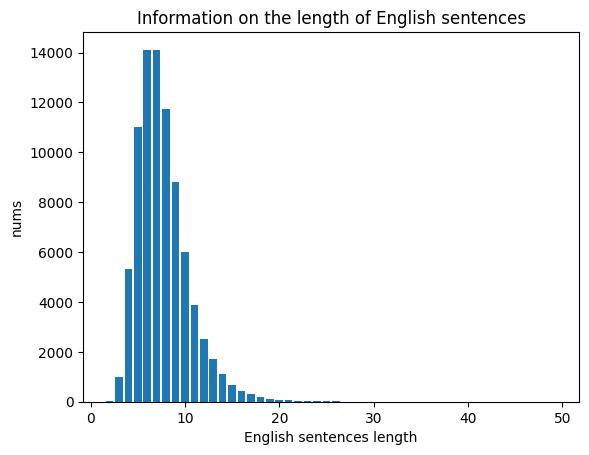

In [11]:
dicta=dict()
for text in train_eng_texts_pre:
    lent=len(text.split())
    if lent in dicta.keys():
        dicta[lent]+=1
    else:
        dicta[lent]=1
lita=sorted(dicta.items(),key=lambda x:x[0],reverse=True)

x=[l[0] for l in lita]
y=[l[1] for l in lita]
plt.bar(x, y)  
plt.xlabel('English sentences length')
plt.ylabel('nums')
plt.title('Information on the length of English sentences')
plt.show()

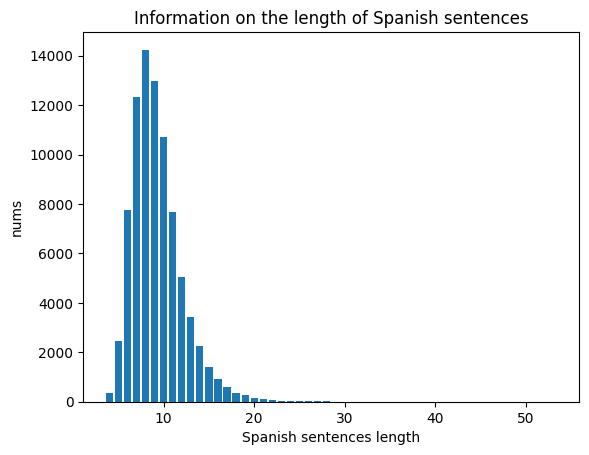

In [12]:
dicta=dict()
for text in train_spa_texts_pre:
    lent=len(text.split())
    if lent in dicta.keys():
        dicta[lent]+=1
    else:
        dicta[lent]=1
lita=sorted(dicta.items(),key=lambda x:x[0],reverse=True)

x=[l[0] for l in lita]
y=[l[1] for l in lita]
plt.bar(x, y)  
plt.xlabel('Spanish sentences length')
plt.ylabel('nums')
plt.title('Information on the length of Spanish sentences')
plt.show()

In [13]:
def build_cropus(data):
    crpous=[]
    for i in range(len(data)):
        cr=data[i].strip().lower()
        cr=cr.split()
        crpous.extend(cr)
    return crpous

eng_crpous=build_cropus(train_eng_texts_pre)
spa_crpous=build_cropus(train_spa_texts_pre)

print(eng_crpous[:3])
print(spa_crpous[:3])


['how', 'can', 'i']
['[start]', '¿', 'cómo']


In [14]:
# According to the given vocabulary, construct a dictionary according to the frequency of word occurrence,
def build_dict(corpus,vocab_size):
    # First count the frequency (number of occurrences) of each different word and use a dictionary record
    word_freq_dict = dict()
    for word in corpus:
        if word not in word_freq_dict:
            word_freq_dict[word] = 0
        word_freq_dict[word] += 1

    # Sort the words in the dictionary according to the number of occurrences. The higher the number of occurrences, the higher the ranking.
    word_freq_dict = sorted(word_freq_dict.items(), key = lambda x:x[1], reverse = True)


    # Construct 2 different dictionaries
    # Mapping relationship between each word and id: word2id_dict
    # Mapping relationship between each id and word: id2word_dict
    word2id_dict = {'<pad>':0,'<unk>':1}
    id2word_dict = {0:'<pad>',1:'<unk>'}

    # Start traversing each word according to frequency, from high to low, and construct a unique id for this word
    i=2
    for word, freq in word_freq_dict:
        if i<vocab_size:
            # curr_id = len(word2id_dict)
            word2id_dict[word] = i
            id2word_dict[i] = word
            i+=1
        else: # Exceeds specified vocabulary, points to
            word2id_dict[word]=1
    return word2id_dict, id2word_dict

In [15]:
vocab_size = 30000 #Set the vocabulary, English and Spanish can be set separately; but to reduce parameters, we set a unified vocabulary here
eng2id_dict,id2eng_dict=build_dict(eng_crpous,vocab_size)
spa2id_dict,id2spa_dict=build_dict(spa_crpous,vocab_size)

print("The total English vocabulary we set is:",vocab_size,'\tThe total English vocabulary we set is:',vocab_size)
print("The total English vocabulary is:",len(eng2id_dict),"\t\tThe actual English vocabulary we use is",len(id2eng_dict))
print("The total Spanish vocabulary is:",len(spa2id_dict),"\tThe actual Spanish vocabulary we use is",len(id2spa_dict))

我们设置的英语总词汇为： 30000 	我们设置的英语总词汇为： 30000
总的英语词汇量为： 11638 		我们实际使用的英语词汇量为 11638
总的西班牙语词汇量为： 22160 	我们实际使用的西班牙语词汇量为 22160


In [16]:
def build_tensor(data,dicta,maxlen):
    tensor=[]
    for i in range(len(data)):
        subtensor=[]
        lista=data[i].split()
        for j in range(len(lista)):
            index=dicta.get(lista[j])
            # For the training solution and test set, there may be words that are not in the vocabulary. In this case, the index will return None.
            if index==None:
                index=1
            subtensor.append(index)
    
        if len(subtensor) < maxlen:
            subtensor+=[0]*(maxlen-len(subtensor))
        else:
            subtensor=subtensor[:maxlen]

        tensor.append(subtensor)
    return np.array(tensor)

In [17]:
sequence_length = 20 # We set the statement length to 20, which can be set separately based on the statistical information summarized in 3.5.

train_eng_tensor=build_tensor(train_eng_texts_pre,eng2id_dict,sequence_length)
val_eng_tensor=build_tensor(val_eng_texts_pre,eng2id_dict,sequence_length)
test_eng_tensor=build_tensor(test_eng_texts_pre,eng2id_dict,sequence_length)

train_spa_tensor=build_tensor(train_spa_texts_pre,spa2id_dict,sequence_length+1)
val_spa_tensor=build_tensor(val_spa_texts_pre,spa2id_dict,sequence_length+1)
test_spa_tensor=build_tensor(test_spa_texts_pre,spa2id_dict,sequence_length+1)

In [18]:
print(val_eng_texts_pre[0])
print(val_eng_tensor[0])

print(val_spa_texts_pre[0])
print(val_spa_tensor[0])

we had a brief discussion about human rights .
[  27   59    8 2803 2217   62 1244 2936    2    0    0    0    0    0
    0    0    0    0    0    0]
[start] tuvimos un breve coloquio sobre los derechos humanos . [end]
[   2  987   16 2686    1  150   26 3160 2726    4    3    0    0    0
    0    0    0    0    0    0    0]


In [19]:
class MyDataset(Dataset):
    """
    步骤一：继承paddle.io.Dataset类
    """
    def __init__(self, eng,spa):
        """
        步骤二：实现构造函数，定义数据集大小
        """
        super(MyDataset, self).__init__()
        self.eng = eng
        self.spa=spa

    def __getitem__(self, index):
        """
        步骤三：实现__getitem__方法，定义指定index时如何获取数据，并返回单条数据（训练数据，对应的标签）
        """
        return self.eng[index], self.spa[index]

    def __len__(self):
        """
        步骤四：实现__len__方法，返回数据集总数目
        """
        return self.eng.shape[0]

In [20]:
def prepare_input(inputs,padid=0):

    src=np.array([inputsub[0] for inputsub in inputs])
    trg=np.array([inputsub[1] for inputsub in inputs])
    trg_mask =(trg[:,:-1]!=padid).astype(paddle.get_default_dtype())
    return src,trg[:,:-1],trg[:,1:,np.newaxis],trg_mask 

In [21]:
# Encapsulated data set

BATCH_SIZE=64 

train_dataset = MyDataset(train_eng_tensor,train_spa_tensor)
train_loader = paddle.io.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,drop_last=True,collate_fn=partial(prepare_input))

val_dataset=MyDataset(val_eng_tensor,val_spa_tensor)
val_loader=paddle.io.DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True,drop_last=True,collate_fn=partial(prepare_input))

In [22]:
for i,data in enumerate(val_loader):
    for d in data:
        print(d.shape)
    break

[64, 20]
[64, 20]
[64, 20, 1]
[64, 20]


paddle.Size([64, 20])
paddle.Size([64, 20])
paddle.Size([64, 20, 1])
paddle.Size([64, 20])


[64, 20]

In [23]:
# Quick validation BLEU scorer function
def compute_validation_bleu(num_samples=100):
    """
    Compute BLEU score on validation set for early monitoring
    num_samples: number of validation samples to evaluate (for speed)
    """
    from sacrebleu.metrics import BLEU
    bleu = BLEU()
    
    trans.eval()
    predictions = []
    references = []
    
    num_to_eval = min(num_samples, len(val_eng_texts))
    
    with paddle.no_grad():
        for i in range(num_to_eval):
            encoder_input = paddle.to_tensor(val_eng_tensor[i], dtype='int64')
            encoder_input = paddle.unsqueeze(encoder_input, axis=0)
            result = beam_decoder.decode(encoder_input)
            predictions.append(result)
            references.append([val_spa_texts[i]])
    
    score = bleu.corpus_score(predictions, references)
    return score.score

In [24]:
# To facilitate network debugging, we define some parameters in advance
embed_dim=256 # Dimensions of word embedding embedding
latent_dim=2048 # Feed forward Related parameters of feed forward neural network
num_heads=8 # The number of ‘heads’ of the multi-head attention mechanism

In [25]:
class TransformerEncoder(paddle.nn.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super(TransformerEncoder, self).__init__()
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = paddle.nn.MultiHeadAttention(num_heads=num_heads, embed_dim=embed_dim, dropout =0.1)

        
        self.dense_proj =paddle.nn.Sequential(
            paddle.nn.Linear(embed_dim, dense_dim), 
            paddle.nn.ReLU(),
            paddle.nn.Linear(dense_dim, embed_dim) )

        self.layernorm_1 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_2 = paddle.nn.LayerNorm(embed_dim)
        self.supports_masking = True

    def forward(self, inputs, mask=None):
        padding_mask=None
        if mask is not None:
            padding_mask = paddle.cast(mask[:, np.newaxis, np.newaxis, :], dtype="int32")
        #print("inputs.shape",inputs.shape)

        attention_output = self.attention(query=inputs, value=inputs, key=inputs, attn_mask=padding_mask)
        #print("attention_output.shape",attention_output.shape)

        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

pencoder=TransformerEncoder(embed_dim, latent_dim, num_heads)
print(pencoder)
inputs=paddle.rand([64,20,256])
print("inputs.shape:",inputs.shape)
out=pencoder(inputs)
print("out.shape:",out.shape)

TransformerEncoder(
  (attention): MultiHeadAttention(
    (q_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (k_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (v_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (out_proj): Linear(in_features=256, out_features=256, dtype=float32)
  )
  (dense_proj): Sequential(
    (0): Linear(in_features=256, out_features=2048, dtype=float32)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=256, dtype=float32)
  )
  (layernorm_1): LayerNorm(normalized_shape=[256], epsilon=1e-05)
  (layernorm_2): LayerNorm(normalized_shape=[256], epsilon=1e-05)
)
inputs.shape: paddle.Size([64, 20, 256])
out.shape: paddle.Size([64, 20, 256])


In [26]:
class PositionalEmbedding(paddle.nn.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim):
        super(PositionalEmbedding, self).__init__()
        self.token_embeddings = paddle.nn.Embedding(num_embeddings =vocab_size, embedding_dim =embed_dim)
        self.position_embeddings = paddle.nn.Embedding(num_embeddings =sequence_length, embedding_dim =embed_dim)

        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def forward(self, inputs):
        length = inputs.shape[-1]
        positions = paddle.arange(start=0, end=length, step=1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def compute_mask(self, inputs, mask=None):
        return paddle.not_equal(inputs, 0)


ps=PositionalEmbedding(20,15000,256)
print(ps)
inputs=paddle.randint(0,15000,[64,20])
print("inputs.shape:",inputs.shape)
out=ps(inputs)
print("out.shape:",out.shape)

PositionalEmbedding(
  (token_embeddings): Embedding(15000, 256, sparse=False, scale_grad_by_freq=False, dtype=paddle.float32)
  (position_embeddings): Embedding(20, 256, sparse=False, scale_grad_by_freq=False, dtype=paddle.float32)
)
inputs.shape: paddle.Size([64, 20])
out.shape: paddle.Size([64, 20, 256])


In [27]:
class TransformerDecoder(paddle.nn.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads):
        super(TransformerDecoder, self).__init__()
        self.embed_dim = embed_dim
        self.latent_dim = latent_dim
        self.num_heads = num_heads
        self.attention_1 = paddle.nn.MultiHeadAttention(num_heads=num_heads, embed_dim=embed_dim)

        self.attention_2 = paddle.nn.MultiHeadAttention(num_heads=num_heads, embed_dim=embed_dim)

        self.dense_proj = paddle.nn.Sequential(
            paddle.nn.Linear(embed_dim, latent_dim), 
            paddle.nn.ReLU(),
            paddle.nn.Linear(latent_dim, embed_dim) )

        self.layernorm_1 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_2 = paddle.nn.LayerNorm(embed_dim)
        self.layernorm_3 = paddle.nn.LayerNorm(embed_dim)
        self.supports_masking = True

    def forward(self, inputs, encoder_outputs, mask=None):
        causal_mask = self.get_causal_attention_mask(inputs) #[batch_size, equence_length, sequence_length]
        padding_mask=None
        if mask is not None:
            padding_mask = paddle.cast(mask[:, np.newaxis, :], dtype="int32")
            padding_mask = paddle.minimum(padding_mask, causal_mask)

        # attn_mask: [batch_size, n_head, sequence_length, sequence_length]
        attention_output_1 = self.attention_1(query=inputs, value=inputs, key=inputs, attn_mask=causal_mask)
        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            attn_mask=padding_mask,
        )

        out_2 = self.layernorm_2(out_1 + attention_output_2)

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + proj_output)

    def get_causal_attention_mask(self, inputs):
        seq_len = inputs.shape[1]
        i = paddle.arange(seq_len)[:, np.newaxis]
        j = paddle.arange(seq_len)
        # shape [1, 1, seq_len, seq_len], using broadcast to automatically adapt to any batch_size
        mask = paddle.cast(i >= j, dtype="int32")
        return paddle.reshape(mask, (1, 1, seq_len, seq_len))

decoder=TransformerDecoder(embed_dim, latent_dim, num_heads)
print(decoder)

inputs=paddle.rand([64,20,256])
enout=paddle.rand([64,20,256])

out=decoder(inputs,enout)
print("out.shape:",out.shape)

TransformerDecoder(
  (attention_1): MultiHeadAttention(
    (q_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (k_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (v_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (out_proj): Linear(in_features=256, out_features=256, dtype=float32)
  )
  (attention_2): MultiHeadAttention(
    (q_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (k_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (v_proj): Linear(in_features=256, out_features=256, dtype=float32)
    (out_proj): Linear(in_features=256, out_features=256, dtype=float32)
  )
  (dense_proj): Sequential(
    (0): Linear(in_features=256, out_features=2048, dtype=float32)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=256, dtype=float32)
  )
  (layernorm_1): LayerNorm(normalized_shape=[256], epsilon=1e-05)
  (layernorm_2): LayerNorm(normalized_shape=[256], epsilon=1e-05)
  (layernorm

In [28]:
class Transformer(paddle.nn.Layer):
    def __init__(self, embed_dim, latent_dim, num_heads,sequence_length, vocab_size):
        super(Transformer, self).__init__()

        self.ps1=PositionalEmbedding(sequence_length, vocab_size, embed_dim)
        self.encoder=TransformerEncoder(embed_dim, latent_dim, num_heads)

        self.ps2=PositionalEmbedding(sequence_length, vocab_size, embed_dim)
        self.decoder=TransformerDecoder(embed_dim, latent_dim, num_heads) 

        # Reduced dropout from 0.5 to 0.2 for better training
        self.drop=paddle.nn.Dropout(p=0.2)

        self.lastLinear=paddle.nn.Linear(embed_dim,vocab_size)

        self.softmax=paddle.nn.Softmax()

    def forward(self,encoder_inputs,decoder_inputs):

        # encoder
        encoder_emb=self.ps1(encoder_inputs)
        encoder_outputs=self.encoder(encoder_emb)

        # decoder
        deocder_emb=self.ps2(decoder_inputs)
        decoder_outputs=self.decoder(deocder_emb,encoder_outputs)

        # dropout
        out=self.drop(decoder_outputs)

        #final output
        out=self.lastLinear(out)
        #out=self.softmax(self.lastLinear(out))

        return out

In [29]:
class CrossEntropy(paddle.nn.Layer):
    def __init__(self, label_smoothing=0.1):
        super(CrossEntropy,self).__init__()
        self.label_smoothing = label_smoothing

    def forward(self,pre,real,trg_mask):
        # Apply label smoothing - prevent overconfidence
        # Smooth the target distribution: target = target * (1 - label_smoothing) + label_smoothing / num_classes
        batch_size, seq_len, vocab_size = pre.shape
        
        if self.label_smoothing > 0:
            # Squeeze the extra dimension from real: [batch_size, seq_len, 1] -> [batch_size, seq_len]
            real_squeezed = paddle.squeeze(real, axis=-1)
            # Convert labels to one-hot
            one_hot = paddle.nn.functional.one_hot(real_squeezed, num_classes=vocab_size)
            # Apply label smoothing
            smoothed_target = one_hot * (1 - self.label_smoothing) + self.label_smoothing / vocab_size
            
            # Cross entropy with smoothed target
            log_probs = paddle.nn.functional.log_softmax(pre, axis=-1)
            cost = -paddle.sum(smoothed_target * log_probs, axis=-1)
        else:
            # The returned data type is consistent with pre. Except for the axis dimension (-1 if not specified), other dimensions are also consistent with pre.
            # logits=pre,[batch_size,sequence_len,word_size], guess that argmax operation will be performed, [batch_size,sequence_len,1]
            # The default soft_label is False, label=real,[bacth_size,sequence_len,1]
            cost=paddle.nn.functional.cross_entropy(input=pre, label=real, reduction='none')
            cost=paddle.squeeze(cost,axis=[2])
        
        # Shape of trg_mask [batch_size,suqence_len]
        # * This asterisk should be multiplied by the corresponding position and the shape of the result returned [bathc_szie,sequence_len]
        masked_cost=cost*trg_mask

        # paddle.mean averages the corresponding positions of the corresponding axis. The result returned here is [sequence_len]
        # The solution method of paddle.sum is consistent with paddle.mean, and the final returned result should be [1]
        return paddle.sum(paddle.mean(masked_cost,axis=[0]))

In [30]:

# Conservative configuration - closer to the original setup but with improvements
epochs_new = 10  # Back to 10 epochs
warmup_steps_new = 500  # Reduce warmup
base_lr_new = 0.0005  # Reduce base learning rate
label_smoothing_new = 0.0  # No need for label smoothing
dropout_p_new = 0.5  # Restore original dropout

# Create new model
trans_new = Transformer(embed_dim, latent_dim, num_heads, sequence_length, vocab_size)

# Update dropout
trans_new.drop.p = dropout_p_new

# New learning rate scheduling function
def get_learning_rate_new(step, warmup_steps=500, total_steps=None, base_lr=0.0005):
    if step < warmup_steps:
        return (step + 1) / warmup_steps * base_lr
    else:
        # Cosine annealing after warmup
        progress = (step - warmup_steps) / (total_steps - warmup_steps) if total_steps else 1.0
        return base_lr * 0.5 * (1.0 + np.cos(np.pi * progress))

# Initialize the optimizer and loss function
optimizer_new = paddle.optimizer.Adam(learning_rate=base_lr_new, parameters=trans_new.parameters())
loss_fn_new = CrossEntropy(label_smoothing=label_smoothing_new)  # No need for label smoothing

# training parameters
max_grad_norm_new = 1.0  # Keep gradient clipping
total_steps_new = epochs_new * len(train_loader)

# Storage metrics
train_losses_new = []
val_losses_new = []
val_bleu_scores_new = []

print(f"\nConfiguration information:")
print(f"  - Epochs: {epochs_new}")
print(f"  - Base LR: {base_lr_new}")
print(f"  - Warmup steps: {warmup_steps_new}")
print(f"  - Label smoothing: {label_smoothing_new}")
print(f"  - Dropout: {dropout_p_new}")
print(f"  - Gradient clipping: {max_grad_norm_new}")
print("\nStart training...\n")

# training loop
global_step_new = 0
for epoch in range(epochs_new):
    train_loss = 0.0
    trans_new.train()
    
    for batch_idx, (src, trg_input, trg_real, trg_mask) in enumerate(train_loader):
        # Convert data type
        src = paddle.to_tensor(src, dtype='int64')
        trg_input = paddle.to_tensor(trg_input, dtype='int64')
        trg_real = paddle.to_tensor(trg_real, dtype='int64')
        trg_mask = paddle.to_tensor(trg_mask, dtype='float32')
        
        # Update learning rate
        lr = get_learning_rate_new(global_step_new, warmup_steps_new, total_steps_new, base_lr_new)
        optimizer_new.set_lr(lr)
        
        # forward propagation
        logits = trans_new(src, trg_input)
        
        # Calculate losses
        loss = loss_fn_new(logits, trg_real, trg_mask)
        
        # Backpropagation
        loss.backward()
        
        # Gradient clipping
        paddle.nn.utils.clip_grad_norm_(trans_new.parameters(), max_grad_norm_new)
        
        optimizer_new.step()
        optimizer_new.clear_grad()
        
        train_loss += loss.item()
        global_step_new += 1
        
        if batch_idx % 100 == 0:
            print(f"Epoch {epoch+1}/{epochs_new}, Batch {batch_idx}, Loss: {loss.item():.4f}, LR: {lr:.6f}")
    
    # verify
    trans_new.eval()
    val_loss = 0.0
    with paddle.no_grad():
        for val_src, val_trg_input, val_trg_real, val_trg_mask in val_loader:
            val_src = paddle.to_tensor(val_src, dtype='int64')
            val_trg_input = paddle.to_tensor(val_trg_input, dtype='int64')
            val_trg_real = paddle.to_tensor(val_trg_real, dtype='int64')
            val_trg_mask = paddle.to_tensor(val_trg_mask, dtype='float32')
            
            val_logits = trans_new(val_src, val_trg_input)
            val_loss_batch = loss_fn_new(val_logits, val_trg_real, val_trg_mask)
            val_loss += val_loss_batch.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_losses_new.append(avg_train_loss)
    val_losses_new.append(avg_val_loss)
    
    print(f"✅ Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}\n")

print("="*60)
print("🎉 New training completed!")
print("="*60)


配置信息:
  - Epochs: 10
  - Base LR: 0.0005
  - Warmup steps: 500
  - Label smoothing: 0.0
  - Dropout: 0.5
  - Gradient clipping: 1.0

开始训练...



c:\Users\zetad\anaconda3\envs\es\lib\site-packages\paddle\tensor\creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(


Epoch 1/10, Batch 0, Loss: 97.3865, LR: 0.000001
Epoch 1/10, Batch 100, Loss: 74.8437, LR: 0.000101
Epoch 1/10, Batch 200, Loss: 53.9059, LR: 0.000201
Epoch 1/10, Batch 300, Loss: 41.6115, LR: 0.000301
Epoch 1/10, Batch 400, Loss: 41.0702, LR: 0.000401
Epoch 1/10, Batch 500, Loss: 37.9215, LR: 0.000500
Epoch 1/10, Batch 600, Loss: 33.9217, LR: 0.000500
Epoch 1/10, Batch 700, Loss: 36.7438, LR: 0.000500
Epoch 1/10, Batch 800, Loss: 32.9567, LR: 0.000499
Epoch 1/10, Batch 900, Loss: 30.7118, LR: 0.000499
Epoch 1/10, Batch 1000, Loss: 31.0666, LR: 0.000498
Epoch 1/10, Batch 1100, Loss: 28.6345, LR: 0.000497
Epoch 1/10, Batch 1200, Loss: 31.9337, LR: 0.000496
Epoch 1/10, Batch 1300, Loss: 24.9311, LR: 0.000495
✅ Epoch 1 - Train Loss: 40.3253, Val Loss: 24.7016

Epoch 2/10, Batch 0, Loss: 22.4084, LR: 0.000495
Epoch 2/10, Batch 100, Loss: 23.1530, LR: 0.000494
Epoch 2/10, Batch 200, Loss: 20.8994, LR: 0.000492
Epoch 2/10, Batch 300, Loss: 19.2726, LR: 0.000491
Epoch 2/10, Batch 400, Loss: 2

In [31]:
import time
from sacrebleu.metrics import BLEU

EVAL_BATCH_SIZE = 256  # Can be adjusted according to video memory

def batch_greedy_decode(eng_tensor_batch, eng_texts_batch):
    B = eng_tensor_batch.shape[0]
    strip_chars = string.punctuation + '¿¡'
    strip_chars = strip_chars.replace('[', '').replace(']', '')
    eng_words_list = [''.join(c for c in t.lower() if c not in strip_chars).split() for t in eng_texts_batch]
    encoder_input = paddle.to_tensor(eng_tensor_batch, dtype='int64')
    decoder_np = np.zeros((B, sequence_length), dtype='int64')
    decoder_np[:, 0] = 2
    finished = np.zeros(B, dtype=bool)
    results = [[] for _ in range(B)]
    unk_counts = np.zeros(B, dtype=int)
    with paddle.no_grad():
        for i in range(sequence_length - 1):
            if finished.all():
                break
            logits = trans_new(encoder_input, paddle.to_tensor(decoder_np, dtype='int64'))
            token_ids = paddle.argmax(logits[:, i, :], axis=-1).numpy()
            for b in range(B):
                if finished[b]: continue
                tid = int(token_ids[b])
                if tid == 3:
                    finished[b] = True
                    continue
                if i + 1 < sequence_length:
                    decoder_np[b, i + 1] = tid
                word = id2spa_dict.get(tid, UNK_TOKEN)
                if word == UNK_TOKEN:
                    ew = eng_words_list[b]
                    if unk_counts[b] < len(ew):
                        word = ew[unk_counts[b]]
                    unk_counts[b] += 1
                if word not in [PAD_TOKEN, START_TOKEN, END_TOKEN]:
                    results[b].append(word)
    return [' '.join(r) for r in results]

def remove_special_tokens(text):
    return text.replace('[start]', '').replace('[end]', '').strip()

references_cleaned = [remove_special_tokens(t) for t in test_spa_texts_pre]

print('\n' + '='*60)
print('📊 Test newly trained models (batch decoding)')
print('='*60)
trans_new.eval()
start_time = time.time()
predictions_cleaned = []
n = len(test_eng_tensor)
for start in range(0, n, EVAL_BATCH_SIZE):
    end = min(start + EVAL_BATCH_SIZE, n)
    predictions_cleaned.extend(batch_greedy_decode(test_eng_tensor[start:end], test_eng_texts[start:end]))
    if end % 2000 == 0 or end == n:
        elapsed = time.time() - start_time
        speed = end / elapsed
        print(f'Progress: {end}/{n} - Speed: {speed:.1f} sentences/second - ETA: {(n-end)/speed:.0f}s')

total_time = time.time() - start_time
print(f'\n✅ Translation completed! Total time taken: {total_time:.1f}s, average speed: {n/total_time:.1f} sentences/second')
for i in range(min(5, n)):
    print(f'\n[{i}] English: {test_eng_texts[i]}')
    print(f'    Reference: {references_cleaned[i]}')
    print(f'    Predicted: {predictions_cleaned[i]}')

with open('result_new.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(predictions_cleaned))

bleu = BLEU()
score_new = bleu.corpus_score(predictions_cleaned, [references_cleaned])
print('\n' + '='*60)
print(f'🎯 BLEU Score: {score_new.score:.2f}')
print(f'   - Precisions: {score_new.precisions}')
print(f'   - BP (Brevity Penalty): {score_new.bp:.4f}')



📊 测试新训练的模型（批量解码）
进度: 17844/17844 - 速度: 2196.9 句子/秒 - ETA: 0s

✅ 翻译完成！总耗时: 8.1s，平均速度: 2196.9 句子/秒

[0] English: My grandpa believes that the moon landing was a hoax.
    Reference: mi abuelo cree que el alunizaje fue un fraude .
    Predicted: mi abuelo cree que el aterrizaje en la luna fue un engaño .

[1] English: He speaks Spanish as well as French.
    Reference: él habla tanto español como francés .
    Predicted: él habla español tan bien como francés .

[2] English: Where did you get all that money from?
    Reference: ¿ de dónde sacaste todo ese dinero ?
    Predicted: ¿ de dónde conseguiste ese dinero ?

[3] English: Do you usually travel alone?
    Reference: ¿ comúnmente viajas solo ?
    Predicted: ¿ normalmente sueles viajar solo ?

[4] English: I didn't recognize Tom the last time I saw him.
    Reference: no reconocí a tom la última vez que lo vi .
    Predicted: no le eché el último rato a tom la vi .


[2026-03-20 21:18:27,887] [ WARNING] base.py:394 - That's 100 lines that end in a tokenized period ('.')
[2026-03-20 21:18:27,887] [ WARNING] base.py:395 - It looks like you forgot to detokenize your test data, which may hurt your score.
[2026-03-20 21:18:27,887] [ WARNING] base.py:398 - If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



🎯 BLEU Score: 43.52
   - Precisions: [72.60914203404894, 50.04881339084438, 36.74259200674892, 27.272255318044362]
   - BP (Brevity Penalty): 0.9963


In [32]:
# Save the trained model
model_save_path = 'transformer_model_final.pdparams'
paddle.save(trans_new.state_dict(), model_save_path)
print(f"✅ Model saved to: {model_save_path}")

# Save all necessary parameters for inference
import json
import pickle

# Create a config dictionary with all necessary information
config = {
    # Model hyperparameters
    'embed_dim': embed_dim,
    'latent_dim': latent_dim,
    'num_heads': num_heads,
    'sequence_length': sequence_length,
    'vocab_size': vocab_size,
    
    # Special tokens
    'START_TOKEN': START_TOKEN,
    'END_TOKEN': END_TOKEN,
    'PAD_TOKEN': PAD_TOKEN,
    'UNK_TOKEN': UNK_TOKEN,
}

# Save config as JSON
config_save_path = 'transformer_config.json'
with open(config_save_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"✅ Config saved to: {config_save_path}")

# Save vocabularies as pickle
vocab_data = {
    'eng2id_dict': eng2id_dict,
    'spa2id_dict': spa2id_dict,
    'id2eng_dict': id2eng_dict,
    'id2spa_dict': id2spa_dict,
}

vocab_save_path = 'transformer_vocab.pkl'
with open(vocab_save_path, 'wb') as f:
    pickle.dump(vocab_data, f)
print(f"✅ Vocabulary saved to: {vocab_save_path}")

# Save test dataset
test_data = {
    'test_eng_tensor': test_eng_tensor,
    'test_spa_tensor': test_spa_tensor,
    'test_eng_texts': test_eng_texts,
    'test_spa_texts': test_spa_texts,
}

test_save_path = 'transformer_test_dataset.pkl'
with open(test_save_path, 'wb') as f:
    pickle.dump(test_data, f)
print(f"✅ Test dataset saved to: {test_save_path}")

print("\nSummary: All files required for inference:")
print(f"1. {model_save_path} - model weight")
print(f"2. {config_save_path} - model configuration (hyperparameters)")
print(f"3. {vocab_save_path} - Vocabulary and dictionary")
print(f"4. {test_save_path} - test set data")

✅ Model saved to: transformer_model_final.pdparams
✅ Config saved to: transformer_config.json
✅ Vocabulary saved to: transformer_vocab.pkl
✅ Test dataset saved to: transformer_test_dataset.pkl

总结：推理所需的全部文件：
1. transformer_model_final.pdparams - 模型权重
2. transformer_config.json - 模型配置（超参数）
3. transformer_vocab.pkl - 词汇表和字典
4. transformer_test_dataset.pkl - 测试集数据


In [33]:
import re
import string

def _translate_sentence(english_text):
    """Translate a single sentence and return the translation string"""
    import re as _re
    _strip = string.punctuation + '¿¡'
    _strip = _strip.replace('[', '').replace(']', '')
    def _tokenize(text):
        out = ''
        for c in text:
            if c not in _strip: out += c
        return out.split()
    # 1. Identify proper nouns
    raw_words = _tokenize(english_text)
    tag_to_word = {}
    counter = 1
    seen = {}
    marked_text = english_text
    for w in raw_words:
        if w[0].isupper() and eng2id_dict.get(w.lower(), 1) == 1:
            if w not in seen:
                seen[w] = counter
                tag_to_word[f'<proper{counter}>'] = w
                counter += 1
            n = seen[w]
            # Replace with pure placeholders (excluding original words to avoid secondary matching)
            marked_text = _re.sub(r'\b' + _re.escape(w) + r'\b', f'XPLACEHOLDERX{n}X', marked_text)
    # Restore placeholder to <properN> word form (preserve the following punctuation to avoid being swallowed by _proper_tag_pat)
    for w, n in seen.items():
        marked_text = _re.sub(
            r'XPLACEHOLDERX' + str(n) + r'X([^\w\s]*)',
            lambda m, _w=w, _n=n: f'<proper{_n}>{_w}' + (' ' + m.group(1) if m.group(1) else ''),
            marked_text
        )

    # 2. Preprocessing: <properN> words are converted into <properN> tokens, and punctuation is retained.
    preprocessed_text = pre_process([marked_text], save_punctuation=True)[0]
    # 3. Numericalize and reason
    eng_tensor_arr = build_tensor([preprocessed_text], eng2id_dict, sequence_length)[0]
    eng_tensor = paddle.to_tensor(eng_tensor_arr, dtype='int64')
    encoder_input = paddle.unsqueeze(eng_tensor, axis=0)
    decoded_tokens = [2]
    decoded_words = []

    with paddle.no_grad():
        for i in range(sequence_length - 1):
            decoder_input = paddle.to_tensor([decoded_tokens], dtype='int64')
            if decoder_input.shape[1] < sequence_length:
                pad_len = sequence_length - decoder_input.shape[1]
                decoder_input = paddle.concat([
                    decoder_input,
                    paddle.zeros([1, pad_len], dtype='int64')
                ], axis=1)
            logits = trans_new(encoder_input, decoder_input)
            current_pos = min(i, sequence_length - 1)
            logits_current = logits[0, current_pos, :]
            probs = paddle.nn.functional.softmax(logits_current)
            sampled_token_index = paddle.argmax(probs).item()
            if sampled_token_index == 3:
                break
            decoded_tokens.append(sampled_token_index)
            sampled_token = id2spa_dict.get(sampled_token_index, UNK_TOKEN)
            if sampled_token not in [PAD_TOKEN, START_TOKEN, END_TOKEN, UNK_TOKEN]:
                # If <properN> token is encountered in the output, directly look up the table to get the corresponding original text.
                if sampled_token in tag_to_word:
                    decoded_words.append(tag_to_word[sampled_token])
                else:
                    decoded_words.append(sampled_token)

    decoded_sentence = ' '.join(decoded_words)
    import re as _re2
    decoded_sentence = _re2.sub(r'(^|(?<=[.?!])\s+)(\S)', lambda m: m.group(1) + m.group(2).upper(), decoded_sentence)
    # Spanish pairwise punctuation completion: yes ? no ¿ then complement ¿ , Yes ! No ¡ Then complement ¡ ,vice versa
    if '?' in decoded_sentence and '¿' not in decoded_sentence:
        decoded_sentence = '¿' + decoded_sentence
    elif '¿' in decoded_sentence and '?' not in decoded_sentence:
        decoded_sentence = decoded_sentence + '?'
    if '!' in decoded_sentence and '¡' not in decoded_sentence:
        decoded_sentence = '¡' + decoded_sentence
    elif '¡' in decoded_sentence and '!' not in decoded_sentence:
        decoded_sentence = decoded_sentence + '!'
    return decoded_sentence

def translate_custom_english(english_text):
    """Sentence-by-sentence translation, supports multi-sentence input"""
    import re as _re3
    # Split sentences by .!?, keeping delimiters
    parts = _re3.split(r'(?<=[.!?])\s+', english_text.strip())
    translated_parts = []
    for part in parts:
        if part.strip():
            translated_parts.append(_translate_sentence(part.strip()))
    result = ' '.join(translated_parts)
    # Capitalize the first letter of a sentence and after punctuation
    import re as _re4
    result = _re4.sub(r'(^|(?<=[.?!])\s+)(\S)', lambda m: m.group(1) + m.group(2).upper(), result)
    return result
print("\n" + "="*60)
print("🎯 English-Spanish translation demonstration system")
print("="*60)

# Example translation
print("\n📝 Example 1: Translate sentences containing common words")
test_sentence1 = "I like eating apples"
print(f"Input: {test_sentence1}")
result1 = translate_custom_english(test_sentence1)
print(f"Output: {result1}\n")

print("📝 Example 2: Translate sentences containing proper nouns")
test_sentence2 = "I love playing Genshin"
print(f"Input: {test_sentence2}")
result2 = translate_custom_english(test_sentence2)
print(f"Output: {result2}\n")

# interactive translation
print("\n" + "="*60)
print("🌐 Interactive translation mode")
print("="*60)
print("Please enter the English sentence you want to translate (enter'exit'quit)")
print("-"*60)

while True:
    user_input = input("\nEnglish input:").strip()
    
    if user_input.lower() == 'exit':
        print("✅ Exit the translation program")
        break
    
    if not user_input:
        print("⚠️ Please enter a non-empty English sentence")
        continue
    
    try:
        print(f"Processing...")
        translation = translate_custom_english(user_input)
        print(f"Translation results: {translation}")
    except Exception as e:
        print(f"❌ Translation error: {str(e)}")


🎯 英西翻译演示系统

📝 示例1: 翻译包含常见词的句子
输入: I like eating apples
输出: Me gustan las manzanas de comer .

📝 示例2: 翻译包含专有名词的句子
输入: I love playing Genshin
输出: Amo a jugar Genshin


🌐 交互式翻译模式
请输入要翻译的英文句子（输入'exit'退出）
------------------------------------------------------------
正在处理...
   翻译结果: ¡ quiero jugar Genshin ! Creo que Genshin es el juego más del mundo , ¿ crees que tú crees ?
✅ 退出翻译程序


## Summary of reasoning changes
### Proper noun translation implementation
**Recognition**: Words whose first letter in the input sentence is capitalized and cannot be found in the English word list (`eng2id_dict.get(w.lower()) == 1`, that is, mapped to `<unk>`) are determined to be proper nouns.
**Replacement Process**:1. Number them in order of appearance, and replace the proper nouns in the original text with pure placeholders `XPLACEHOLDERX{n}X` (use `\b` word boundaries to avoid mismatches)2. Use the regular `XPLACEHOLDERX{n}X([^\w\s]*)` when restoring to simultaneously capture the following punctuation and restore it to `<proper{n}>word punctuation` (add a space between the punctuation point and the word) to prevent `_proper_tag_pat` from swallowing the punctuation together.3. In `pre_process`, `_proper_tag_pat = re.compile(r'(<proper\d+>)(\S+)')` replaces the entire `<proper{n}> word` with the placeholder `PROPTOKEN{n}`, lowercasing and punctuation processing and then restores it to `<proper{n}>` token and sends it to the model4. The `<proper{n}>` token output during decoding is directly exchanged back to the original proper noun through the `tag_to_word` dictionary.
**The same proper noun appears multiple times**: `seen` dictionary records have been assigned numbers, and the same word reuses the same number. Use `re.sub` to replace placeholders globally to avoid secondary matching.
### Other changes
- **Translation by sentence**: `translate_custom_english` Press `(?<=[.!?])\s+` to split multiple sentences, call `_translate_sentence` sentence by sentence and then splice them together, the first letter of the sentence is capitalized- **Batch inference acceleration**: Use `batch_greedy_decode` (`EVAL_BATCH_SIZE=256`) instead when evaluating, remove softmax and use argmax directly, and the speed is greatly improved.- **causal mask broadcast**: `get_causal_attention_mask` returns `[1,1,seq,seq]` shape, using broadcast to adapt to any batch size, no more hard coding- **Spanish paired punctuation**: `?` but not `¿ in the translation ` then complement `¿ `, there is `¿ ` If there is no `?`, then complement `?`; `!` and `¡ `Similarly